In [12]:
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt 

In [35]:
def calibrate_stereo(nb_vertical, nb_horizontal, dataset):
    objp = np.zeros((nb_horizontal * nb_vertical, 3), np.float32)
    objp[:,:2] = np.mgrid[0:nb_vertical, 0:nb_horizontal].T.reshape(-1,2)

    objpoints = []
    img_points_left, img_points_right = [], []

    images_left = sorted(glob.glob(f'{dataset}/left*.png'))
    images_right = sorted(glob.glob(f'{dataset}/right*.png'))

    criteria = criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

    assert len(images_left) == len(images_right)
    processed = 0

    for img_left, img_right in zip(images_left, images_right):
        img_left = cv2.imread(img_left)
        img_right = cv2.imread(img_right)

        gray_l = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
        gray_r = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

        retl, cornersl = cv2.findChessboardCorners(gray_l, (nb_vertical, nb_horizontal))
        retr, cornersr = cv2.findChessboardCorners(gray_r, (nb_vertical, nb_horizontal))

        if retl and retr:
            cornersl = cv2.cornerSubPix(gray_l, cornersl, (10, 10), (-1, -1), criteria)
            cornersr = cv2.cornerSubPix(gray_r, cornersr, (10,10), (-1,-1), criteria)

            objpoints.append(objp)
            img_points_left.append(cornersl)
            img_points_right.append(cornersr)
            processed += 1

    print(f"Corners found in {processed} image pairs")

    img_size = gray_l.shape[::-1]

    retl, mtx_l, dist_l, _, _ = cv2.calibrateCamera(objpoints, img_points_left, img_size, None, None)
    retr, mtx_r, dist_r, _, _ = cv2.calibrateCamera(objpoints, img_points_right, img_size, None, None)

    stereo_criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)
    stereo_flags = cv2.CALIB_FIX_INTRINSIC

    ret_stereo, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F = cv2.stereoCalibrate(
        objpoints, img_points_left, img_points_right,
        mtx_l, dist_l, mtx_r, dist_r, img_size,
        criteria=stereo_criteria, flags=stereo_flags
    )

    return ret_stereo, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F

def get_image_shape(dataset):
    img = cv2.imread(f'{dataset}/left-0000.png', cv2.IMREAD_GRAYSCALE)
    return img.shape[::-1]

In [41]:
ds = 'mynteye'
ret_stereo, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F = calibrate_stereo(9, 6, ds)
print(f"Overall RMS: {ret_stereo}")
shape = get_image_shape(ds)

new_camera_matrix_l, roi_l = cv2.getOptimalNewCameraMatrix(mtx_l, dist_l, shape, 1, shape)
new_camera_matrix_r, roi_r = cv2.getOptimalNewCameraMatrix(mtx_r, dist_r, shape, 1, shape)


print(f"New camera matrix l {new_camera_matrix_l}\n roi_l {roi_l}")
print(f"New camera matrix r {new_camera_matrix_r}\n roi_l {roi_r}")

Corners found in 50 image pairs
Overall RMS: 0.3165072025711771
New camera matrix l [[281.86781602   0.         593.68480128]
 [  0.         323.9999245  338.60746976]
 [  0.           0.           1.        ]]
 roi_l (345, 167, 512, 331)
New camera matrix r [[9.58956575e+01 0.00000000e+00 1.11136723e+03]
 [0.00000000e+00 1.20915281e+02 6.10384262e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
 roi_l (1023, 546, 175, 124)


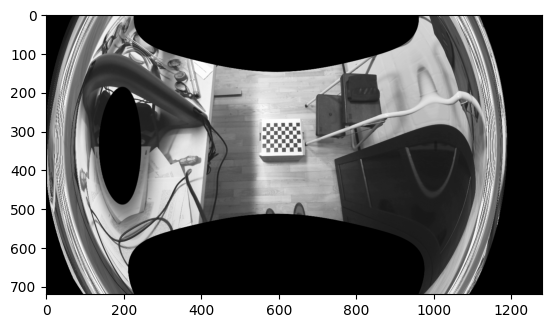

In [42]:
img_left = cv2.imread(f'{ds}/left-0000.png', cv2.IMREAD_GRAYSCALE)
img_right = cv2.imread(f'{ds}/right-0000.png', cv2.IMREAD_GRAYSCALE)

dst_l = cv2.undistort(img_left, mtx_l, dist_l, None, new_camera_matrix_l)
dst_r = cv2.undistort(img_right, mtx_r, dist_r, None, new_camera_matrix_r)

plt.imshow(dst_l, cmap='gray')

In [43]:

R1, R2, P1, P2, Q, roi_l, roi_r = cv2.stereoRectify(
    mtx_l, dist_l, mtx_r, dist_r, shape, R, T,
    flags=cv2.CALIB_ZERO_DISPARITY, alpha=0
)

map_l_x, map_l_y = cv2.initUndistortRectifyMap(mtx_l, dist_l, R1, P1, shape, cv2.CV_32FC1)
map_r_x, map_r_y = cv2.initUndistortRectifyMap(mtx_r, dist_r, R2, P2, shape, cv2.CV_32FC1)

In [44]:
rectified_l = cv2.remap(img_left, map_l_x, map_l_y, cv2.INTER_LINEAR)
rectified_r = cv2.remap(img_right, map_r_x, map_r_y, cv2.INTER_LINEAR)

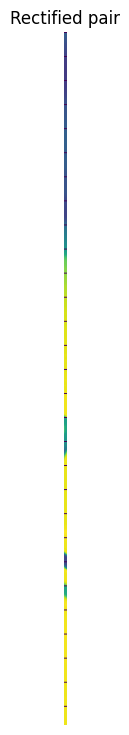

In [45]:
stacked = np.hstack((rectified_l, rectified_r))
stacked_lines = stacked.copy()
for y in range(0, stacked_lines.shape[0], 25):
    cv2.line(stacked_lines, (0, y), (stacked_lines.shape[1], y), (0, 255, 0), 1)

plt.figure(figsize=(18, 9))
plt.imshow(stacked_lines[..., [2, 1, 0]])
plt.title("Rectified pair")
plt.axis('off')
plt.show()


In [20]:
def absSumDiffImage(img1, img2):
    # if img1.shape != img2.shape:
    #     raise ValueError("Images must have the same dimensions!")
    return np.sum(np.abs(img1.astype(np.int16) - img2.astype(np.int16)))

def findMatch(img_slice, template):
    # Count how many columns img_slice has
    span = img_slice.shape[1]
    # Create an array of zeros, one for each column --> Each value will have the matching score for that position
    difs_span = np.zeros(span)

    # Assuming height is always 7, with 4 as middle pixel
    for i in range(span):
        # skip centres where the 7-column block would go outside the image
        if i < 3 or i > span -4:
            difs_span[i] = np.inf
            continue

        # Selecting all rows and 7 columns centred at column i (the end index i+4 is excluded)
        img_current = img_slice[:,i-3:i+4]
        
        # Calculate the sum of absolute differences between this block and the template: a lower score means a better match in pixel values
        difs_span[i] = float(absSumDiffImage(img_current, template))
    
    # Returns index for which the dif was lowest ie best match
    return np.argmin(difs_span) 


def disparity(img_left, img_right):
    movement_map = np.zeros_like(img_left) #The movement map should only be in 2D
    print(img_left.shape, img_right.shape)
    rows = movement_map.shape[0]
    columns = movement_map.shape[1]
    
    for i in range(rows):
        if i%10 == 0:
            print("Rows are", int((i/rows)*100),r"% finished")
        for j in range(columns):
            if (i < 3 or i > rows -4) or (j < 3 or j > columns -4):
                #We assume no movement on the edges since we cannot compute it
                movement_map[i,j] = 0
                continue

            current_template = img_left[i-3:i+4,j-3:j+4]
            movement_map[i,j] = findMatch(img_right[i-3:i+4,:],current_template) - j 
    # subtract j as it is the current column index and we want movement not position of match 
    print(f"Rows are 100 % finished")
    return movement_map

(480, 640, 3) (480, 640, 3)
Rows are 0 % finished
Rows are 2 % finished
Rows are 4 % finished
Rows are 6 % finished
Rows are 8 % finished
Rows are 10 % finished
Rows are 12 % finished
Rows are 14 % finished
Rows are 16 % finished
Rows are 18 % finished
Rows are 20 % finished
Rows are 22 % finished
Rows are 25 % finished
Rows are 27 % finished
Rows are 29 % finished
Rows are 31 % finished
Rows are 33 % finished
Rows are 35 % finished
Rows are 37 % finished
Rows are 39 % finished
Rows are 41 % finished
Rows are 43 % finished
Rows are 45 % finished
Rows are 47 % finished
Rows are 50 % finished
Rows are 52 % finished
Rows are 54 % finished
Rows are 56 % finished
Rows are 58 % finished
Rows are 60 % finished
Rows are 62 % finished
Rows are 64 % finished
Rows are 66 % finished
Rows are 68 % finished
Rows are 70 % finished
Rows are 72 % finished
Rows are 75 % finished
Rows are 77 % finished
Rows are 79 % finished
Rows are 81 % finished
Rows are 83 % finished
Rows are 85 % finished
Rows are 87

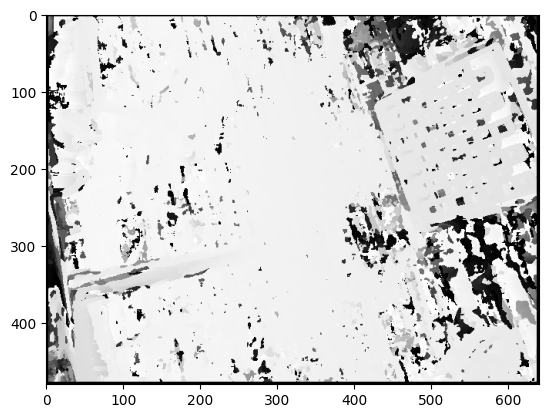

In [21]:
result = disparity(rectified_l, rectified_r)
plt.imshow(result, cmap='viridis')

Average movement is: 3.1210123697916665


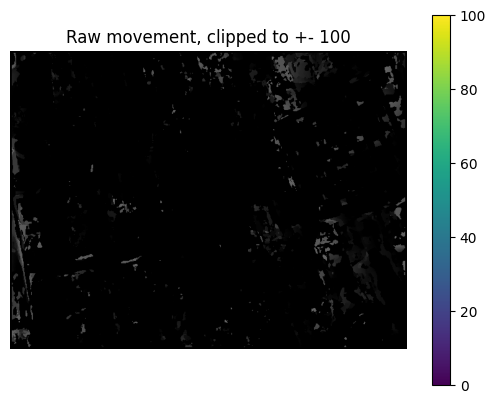

In [26]:
movement_map_copy = result.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 100) | (movement_map_copy < -100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Raw movement, clipped to +- 100")
plt.show()

Average movement is: 209.953720703125


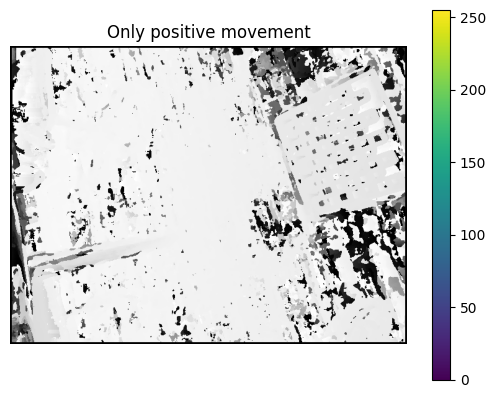

In [27]:
movement_map_copy = result.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy < 0)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only positive movement")
plt.show()

Average movement is: 0.0


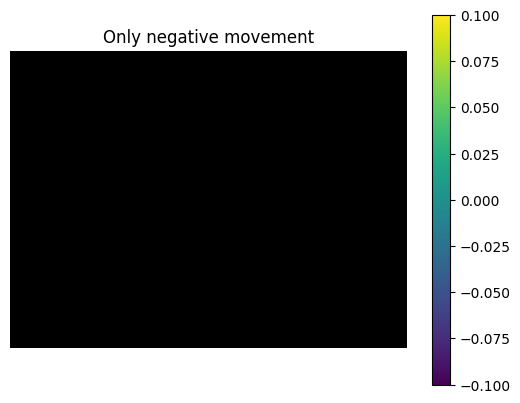

In [28]:
movement_map_copy = result.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 0)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only negative movement")
plt.show()

Average movement is: 0.0


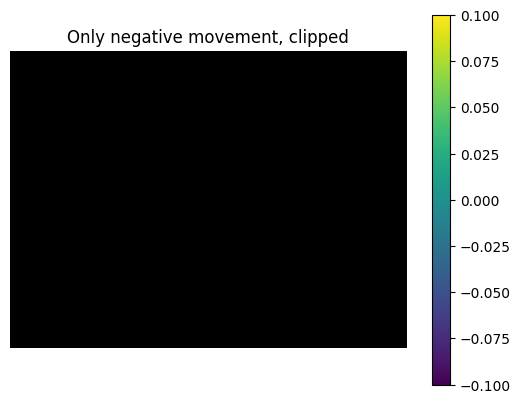

In [25]:
movement_map_copy = result.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 0) | (movement_map_copy < -100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only negative movement, clipped")
plt.show()